# Seoul Bike Sharing Demand — Complete EDA
**Course:** CMP5366 Data Management and Machine Learning Operations  
**Dataset:** Seoul Bike Sharing Demand (8,760 hourly records, 2017–2018)

## Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
})

BLUE  = '#2E75B6'
CORAL = '#E05C5C'
GREEN = '#4CAF50'
AMBER = '#FF8C00'
SEASON_COLORS = {
    'Spring': '#4CAF50',
    'Summer': '#FF8C00',
    'Autumn': '#B5651D',
    'Winter': '#2E75B6',
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load & Inspect Data

In [2]:
COLUMN_MAP = {
    'Date':                         'date',
    'Rented Bike Count':            'rented_bike_count',
    'Hour':                         'hour',
    'Temperature(\u00b0C)':         'temperature_c',
    'Humidity(%)':                  'humidity_pct',
    'Wind speed (m/s)':             'wind_speed_ms',
    'Visibility (10m)':             'visibility_10m',
    'Dew point temperature(\u00b0C)':'dew_point_temp_c',
    'Solar Radiation (MJ/m2)':      'solar_radiation_mj',
    'Rainfall(mm)':                 'rainfall_mm',
    'Snowfall (cm)':                'snowfall_cm',
    'Seasons':                      'seasons',
    'Holiday':                      'holiday',
    'Functioning Day':              'functioning_day',
}

df = pd.read_csv('data/SeoulBikeData.csv', encoding='utf-8-sig')
df.columns = df.columns.str.strip()
df.rename(columns=COLUMN_MAP, inplace=True)
df['date']        = pd.to_datetime(df['date'], format='%d/%m/%Y')
df['month']       = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()

print(f'Shape          : {df.shape}')
print(f'Date range     : {df["date"].min().date()} \u2192 {df["date"].max().date()}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicates     : {df.duplicated().sum()}')

NUMERIC_COLS = [
    'rented_bike_count', 'hour', 'temperature_c', 'humidity_pct',
    'wind_speed_ms', 'visibility_10m', 'dew_point_temp_c',
    'solar_radiation_mj', 'rainfall_mm', 'snowfall_cm', 'month',
]

Shape          : (8760, 16)
Date range     : 2017-12-01 → 2018-11-30
Missing values : 0
Duplicates     : 0


In [3]:
df.head()

,date,rented_bike_count,hour,temperature_c,humidity_pct,wind_speed_ms,visibility_10m,dew_point_temp_c,solar_radiation_mj,rainfall_mm,snowfall_cm,seasons,holiday,functioning_day,month,day_of_week
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rented_bike_count,8760.0,704.602055,644.997468,0.0,191.00,504.50,1065.25,3556.00
hour,8760.0,11.500000,6.922582,0.0,5.75,11.50,17.25,23.00
temperature_c,8760.0,12.882922,11.944825,-17.8,3.50,13.70,22.50,39.40
humidity_pct,8760.0,58.226256,20.362413,0.0,42.00,57.00,74.00,98.00
wind_speed_ms,8760.0,1.724909,1.036300,0.0,0.90,1.50,2.30,7.40
visibility_10m,8760.0,1436.825799,608.298712,27.0,940.00,1698.00,2000.00,2000.00
dew_point_temp_c,8760.0,4.073813,13.060369,-30.6,-4.70,5.10,14.80,27.20
solar_radiation_mj,8760.0,0.569111,0.868746,0.0,0.00,0.01,0.93,3.52
rainfall_mm,8760.0,0.148687,1.128193,0.0,0.00,0.00,0.00,35.00
snowfall_cm,8760.0,0.075068,0.436746,0.0,0.00,0.00,0.00,8.80


## Figure 1 — Target Variable Distribution
**Report placement:** Section 5.1 → *Distributions*  
Supports: *"Rented bike count is right-skewed, with a tail of high-demand peaks during commuting hours"*

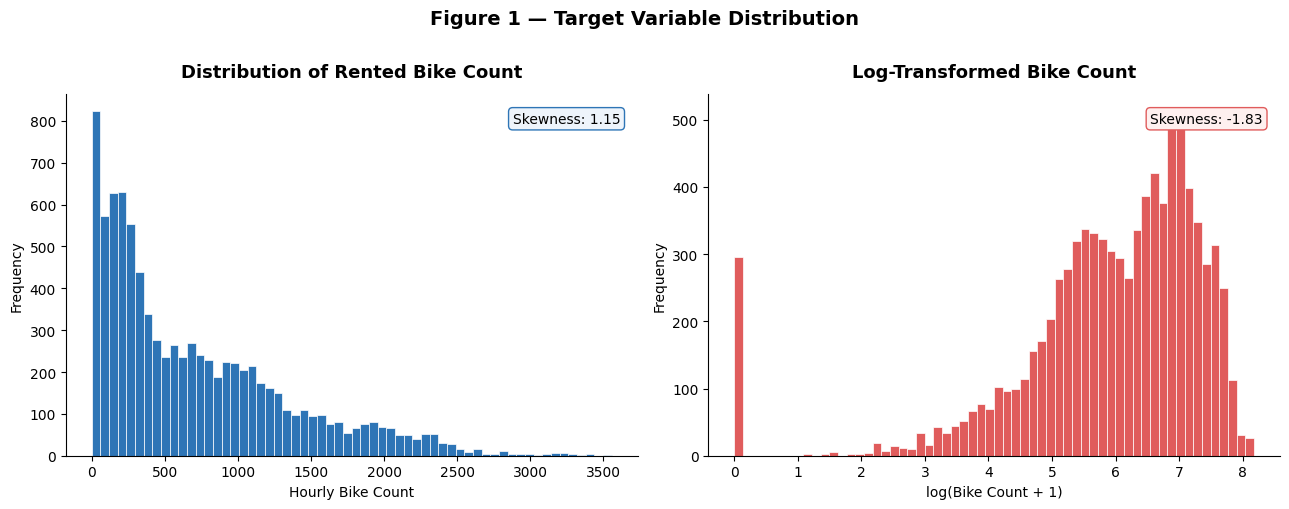

Skewness original: 1.15 | log: -1.83


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['rented_bike_count'], bins=60, color=BLUE,
             edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Rented Bike Count',
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Hourly Bike Count')
axes[0].set_ylabel('Frequency')
axes[0].text(0.97, 0.95,
             f'Skewness: {df["rented_bike_count"].skew():.2f}',
             transform=axes[0].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#EEF4FB', edgecolor=BLUE))

log_vals = np.log1p(df['rented_bike_count'])
axes[1].hist(log_vals, bins=60, color=CORAL,
             edgecolor='white', linewidth=0.5)
axes[1].set_title('Log-Transformed Bike Count',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('log(Bike Count + 1)')
axes[1].set_ylabel('Frequency')
axes[1].text(0.97, 0.95,
             f'Skewness: {log_vals.skew():.2f}',
             transform=axes[1].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FEF0EF', edgecolor=CORAL))

plt.suptitle('Figure 1 \u2014 Target Variable Distribution',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Skewness original: {df["rented_bike_count"].skew():.2f} | log: {log_vals.skew():.2f}')

## Figure 2 — Average Hourly Demand Pattern
**Report placement:** Section 5.1 → *Relationships Between Features and Target* + Section 5.2  
Supports: *"hour averages 1,503 rentals at 18:00 against 133 at 04:00"*

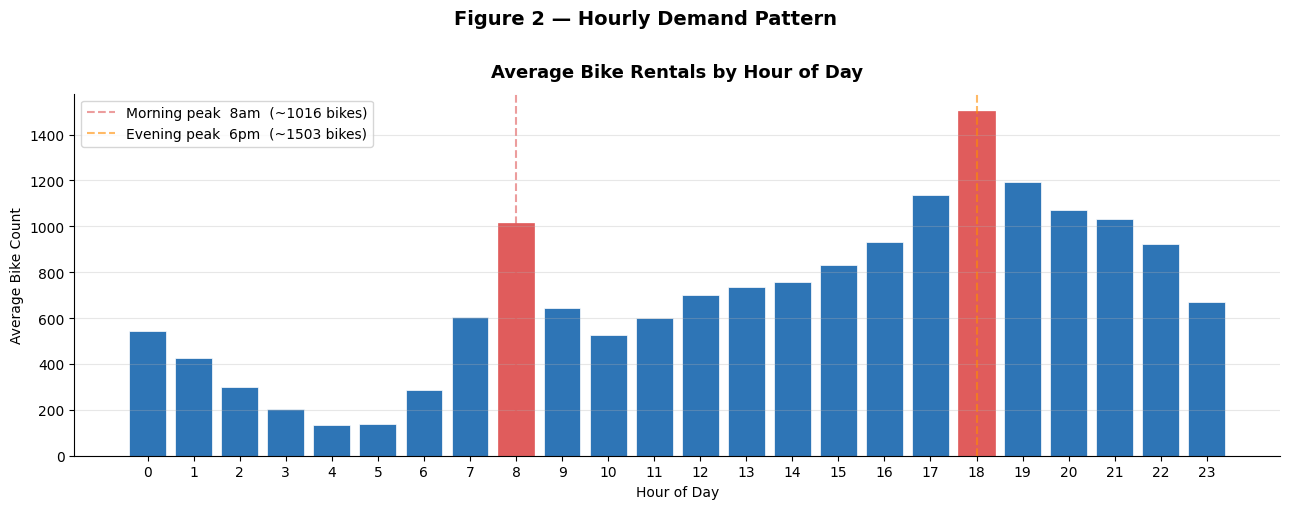

Peak: 18:00 → 1503 bikes  |  Low:  4:00 → 133 bikes


In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

hourly = df.groupby('hour')['rented_bike_count'].mean()
bars = ax.bar(hourly.index, hourly.values, color=BLUE,
              edgecolor='white', linewidth=0.5)
for i in [8, 18]:
    bars[i].set_color(CORAL)

ax.axvline(x=8,  color=CORAL, linestyle='--', alpha=0.6,
           label=f'Morning peak  8am  (~{hourly[8]:.0f} bikes)')
ax.axvline(x=18, color=AMBER, linestyle='--', alpha=0.6,
           label=f'Evening peak  6pm  (~{hourly[18]:.0f} bikes)')
ax.set_title('Average Bike Rentals by Hour of Day',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Bike Count')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Figure 2 \u2014 Hourly Demand Pattern',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig2_hourly_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Peak: {hourly.idxmax()}:00 \u2192 {hourly.max():.0f} bikes  |  '
      f'Low:  {hourly.idxmin()}:00 \u2192 {hourly.min():.0f} bikes')

## Figure 3 — Seasonal Demand
**Report placement:** Section 5.1 → *Distributions* + Section 5.2  
Supports: *"summer-to-winter demand gap of 1,050 versus 210 rentals per hour"*

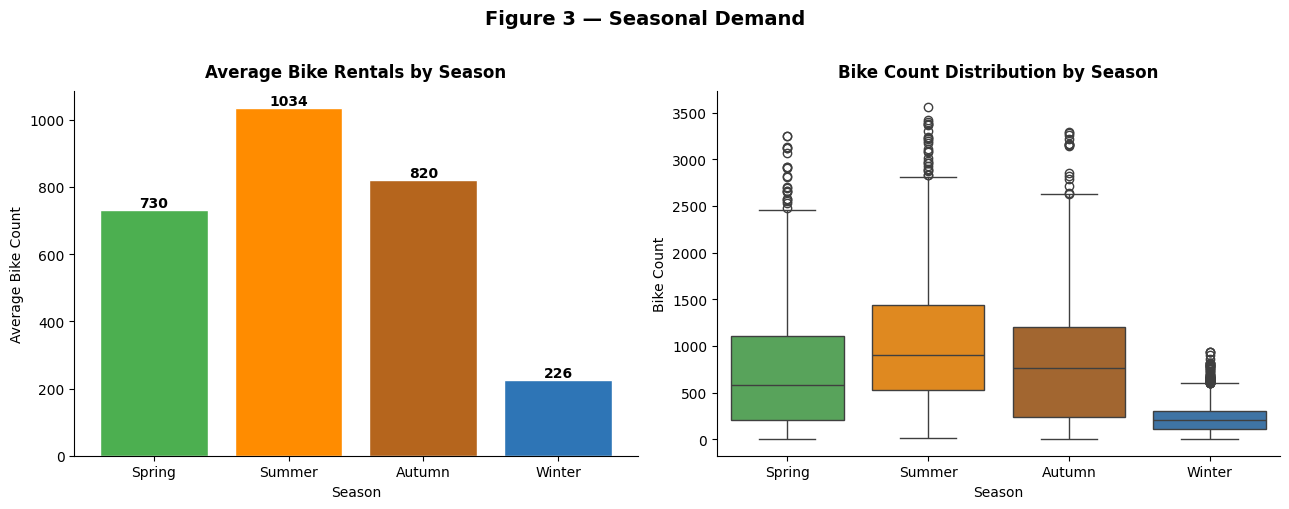

Seasonal averages:
seasons
Spring     730.031250
Summer    1034.073370
Autumn     819.597985
Winter     225.541204


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_avg   = df.groupby('seasons')['rented_bike_count'].mean().reindex(season_order)
bar_colors   = [SEASON_COLORS[s] for s in season_order]

axes[0].bar(season_avg.index, season_avg.values,
            color=bar_colors, edgecolor='white')
for i, v in enumerate(season_avg.values):
    axes[0].text(i, v + 10, f'{v:.0f}',
                 ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Average Bike Rentals by Season',
                  fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average Bike Count')

sns.boxplot(data=df, x='seasons', y='rented_bike_count',
            order=season_order, hue='seasons',
            palette={s: SEASON_COLORS[s] for s in season_order},
            legend=False, ax=axes[1])
axes[1].set_title('Bike Count Distribution by Season',
                  fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Bike Count')

plt.suptitle('Figure 3 \u2014 Seasonal Demand',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig3_seasonal_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print('Seasonal averages:')
print(season_avg.to_string())

## Figure 4 — Temperature vs Demand
**Report placement:** Section 5.1 → *Relationships Between Features and Target*  
Supports: *"Temperature has the highest correlation with the target at +0.539 ... non-linearity linear model cannot capture"*

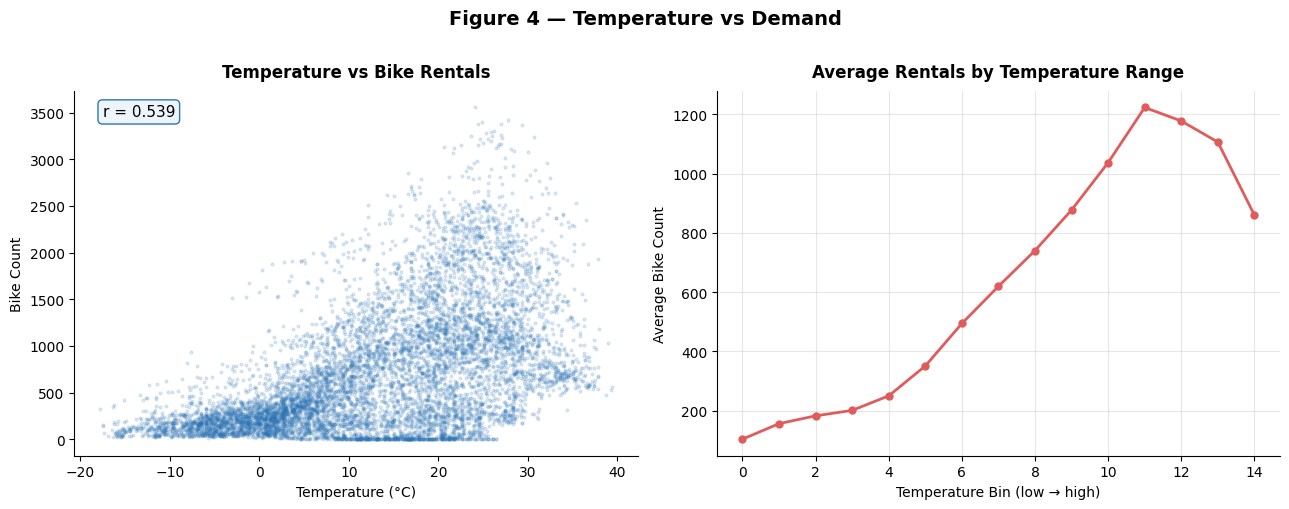

Temperature correlation with target: 0.539


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['temperature_c'], df['rented_bike_count'],
                alpha=0.15, color=BLUE, s=4)
axes[0].set_title('Temperature vs Bike Rentals',
                  fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Temperature (\u00b0C)')
axes[0].set_ylabel('Bike Count')
r_temp = df['temperature_c'].corr(df['rented_bike_count'])
axes[0].text(0.05, 0.93, f'r = {r_temp:.3f}',
             transform=axes[0].transAxes, fontsize=11,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#EEF4FB', edgecolor=BLUE))

df['temp_bin'] = pd.cut(df['temperature_c'], bins=15)
temp_avg = df.groupby('temp_bin', observed=True)['rented_bike_count'].mean()
axes[1].plot(range(len(temp_avg)), temp_avg.values,
             marker='o', color=CORAL, linewidth=2, markersize=5)
axes[1].set_title('Average Rentals by Temperature Range',
                  fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Temperature Bin (low \u2192 high)')
axes[1].set_ylabel('Average Bike Count')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 4 \u2014 Temperature vs Demand',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig4_temperature_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Temperature correlation with target: {r_temp:.3f}')

## Figure 5 — Correlation Heatmap
**Report placement:** Section 5.1 → *Relationships Between Feature Variables*  
Supports: *"Temperature and dew point exhibit strong collinearity / hour and solar radiation are non-linearly correlated"*

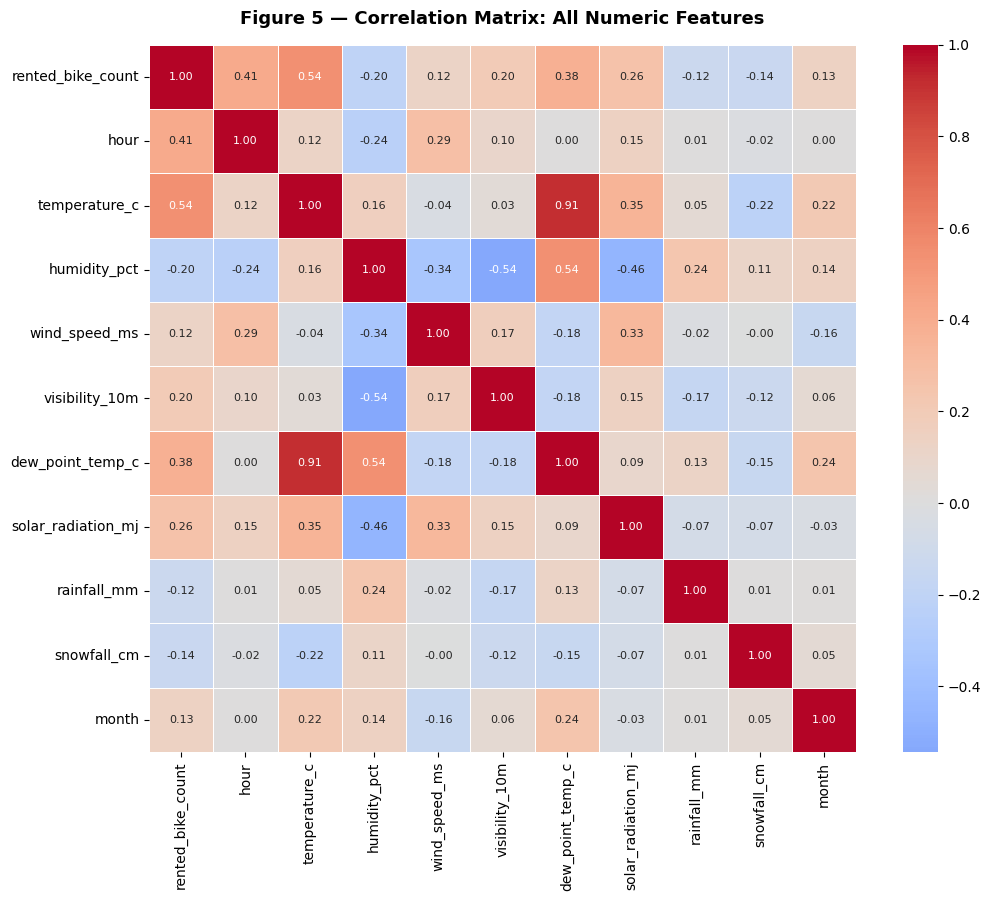

Top correlations with rented_bike_count:
temperature_c         0.538558
hour                  0.410257
dew_point_temp_c      0.379788
solar_radiation_mj    0.261837
visibility_10m        0.199280
month                 0.133514
wind_speed_ms         0.121108
rainfall_mm          -0.123074
snowfall_cm          -0.141804
humidity_pct         -0.199780


In [9]:
fig, ax = plt.subplots(figsize=(11, 9))

corr_matrix = df[NUMERIC_COLS].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Figure 5 \u2014 Correlation Matrix: All Numeric Features',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('figures/fig5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top correlations with rented_bike_count:')
top_corr = (corr_matrix['rented_bike_count']
            .drop('rented_bike_count')
            .sort_values(ascending=False))
print(top_corr.to_string())

## Figure 6 — Holiday vs Non-Holiday Pattern
**Report placement:** Section 5.1 → *Relationships Between Features and Target* + Section 5.2  
Supports: *"Non-holiday hours record 43% more rentals than holiday hours on average"*

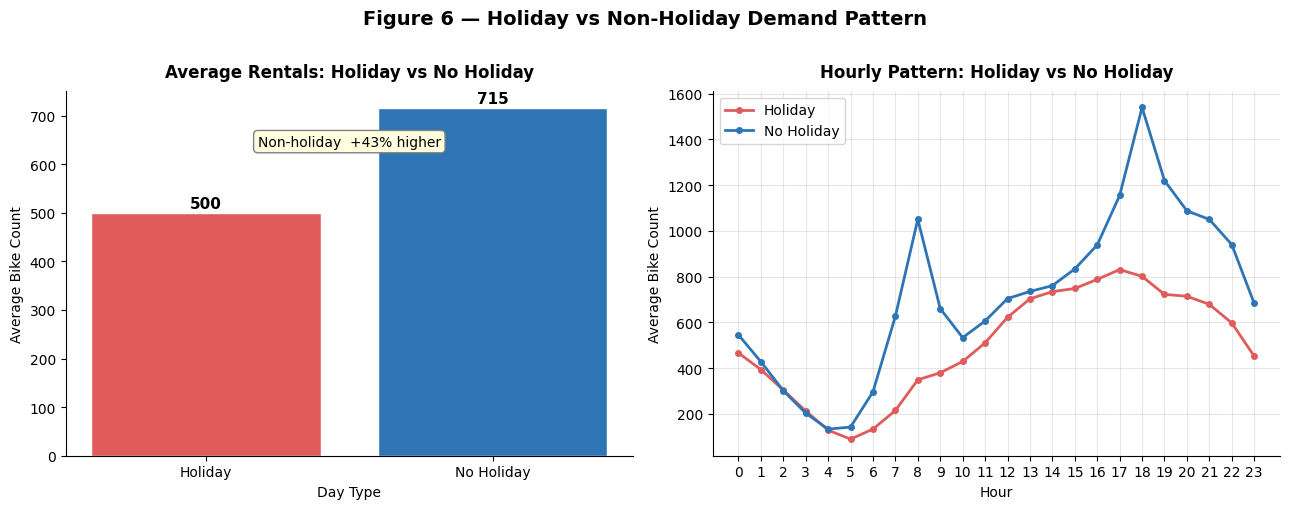

Holiday avg: 500  |  No Holiday avg: 715  (+43%)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

holiday_avg = (df.groupby('holiday')['rented_bike_count']
                 .mean()
                 .reindex(['Holiday', 'No Holiday']))
axes[0].bar(holiday_avg.index, holiday_avg.values,
            color=[CORAL, BLUE], edgecolor='white')
for i, v in enumerate(holiday_avg.values):
    axes[0].text(i, v + 10, f'{v:.0f}',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Average Rentals: Holiday vs No Holiday',
                  fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Day Type')
axes[0].set_ylabel('Average Bike Count')
diff_pct = ((holiday_avg['No Holiday'] - holiday_avg['Holiday'])
            / holiday_avg['Holiday'] * 100)
axes[0].text(0.5, 0.85, f'Non-holiday  +{diff_pct:.0f}% higher',
             transform=axes[0].transAxes, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))

holiday_hourly = (df.groupby(['hour', 'holiday'])['rented_bike_count']
                    .mean().unstack())
for col, color in zip(holiday_hourly.columns, [CORAL, BLUE]):
    axes[1].plot(holiday_hourly.index, holiday_hourly[col],
                 marker='o', linewidth=2, markersize=4,
                 label=col, color=color)
axes[1].set_title('Hourly Pattern: Holiday vs No Holiday',
                  fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Average Bike Count')
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('Figure 6 \u2014 Holiday vs Non-Holiday Demand Pattern',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig6_holiday_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Holiday avg: {holiday_avg["Holiday"]:.0f}  |  '
      f'No Holiday avg: {holiday_avg["No Holiday"]:.0f}  (+{diff_pct:.0f}%)')

## Figure 7 — Functioning Day & Outlier Detection
**Report placement:** Section 5.1 → *Outliers and Missing Values*  
Supports: *"295 non-functioning day rows excluded / high-count outliers represent genuine summer demand spikes"*

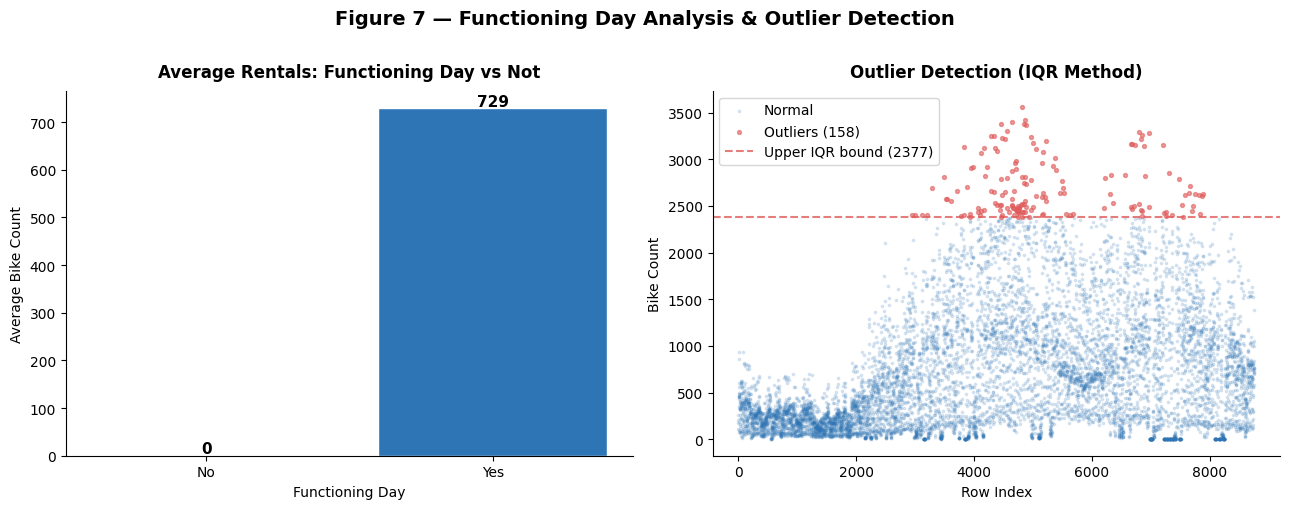

Non-functioning rows : 295
IQR upper bound      : 2377
Outliers detected    : 158 (1.8%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

func_avg = (df.groupby('functioning_day')['rented_bike_count']
              .mean().reindex(['No', 'Yes']))
axes[0].bar(func_avg.index, func_avg.values,
            color=[CORAL, BLUE], edgecolor='white')
for i, v in enumerate(func_avg.values):
    axes[0].text(i, v + 5, f'{v:.0f}',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Average Rentals: Functioning Day vs Not',
                  fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Functioning Day')
axes[0].set_ylabel('Average Bike Count')

Q1      = df['rented_bike_count'].quantile(0.25)
Q3      = df['rented_bike_count'].quantile(0.75)
IQR     = Q3 - Q1
upper   = Q3 + 1.5 * IQR
outliers = df[df['rented_bike_count'] > upper]
normal   = df[df['rented_bike_count'] <= upper]
axes[1].scatter(normal.index, normal['rented_bike_count'],
                alpha=0.15, s=3, color=BLUE, label='Normal')
axes[1].scatter(outliers.index, outliers['rented_bike_count'],
                alpha=0.6, s=8, color=CORAL,
                label=f'Outliers ({len(outliers)})')
axes[1].axhline(y=upper, color=CORAL, linestyle='--', alpha=0.8,
                label=f'Upper IQR bound ({upper:.0f})')
axes[1].set_title('Outlier Detection (IQR Method)',
                  fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Row Index')
axes[1].set_ylabel('Bike Count')
axes[1].legend()

plt.suptitle('Figure 7 \u2014 Functioning Day Analysis & Outlier Detection',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig7_outliers_functioning.png', dpi=150, bbox_inches='tight')
plt.show()
non_func = (df['functioning_day'] == 'No').sum()
print(f'Non-functioning rows : {non_func}')
print(f'IQR upper bound      : {upper:.0f}')
print(f'Outliers detected    : {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

## Figure 8 — Monthly & Temporal Trends
**Report placement:** Section 5.1 → *Distributions* + Section 5.2  
Supports: *"summer-to-winter demand gap / seasonal fleet planning would benefit from model forecasts"*

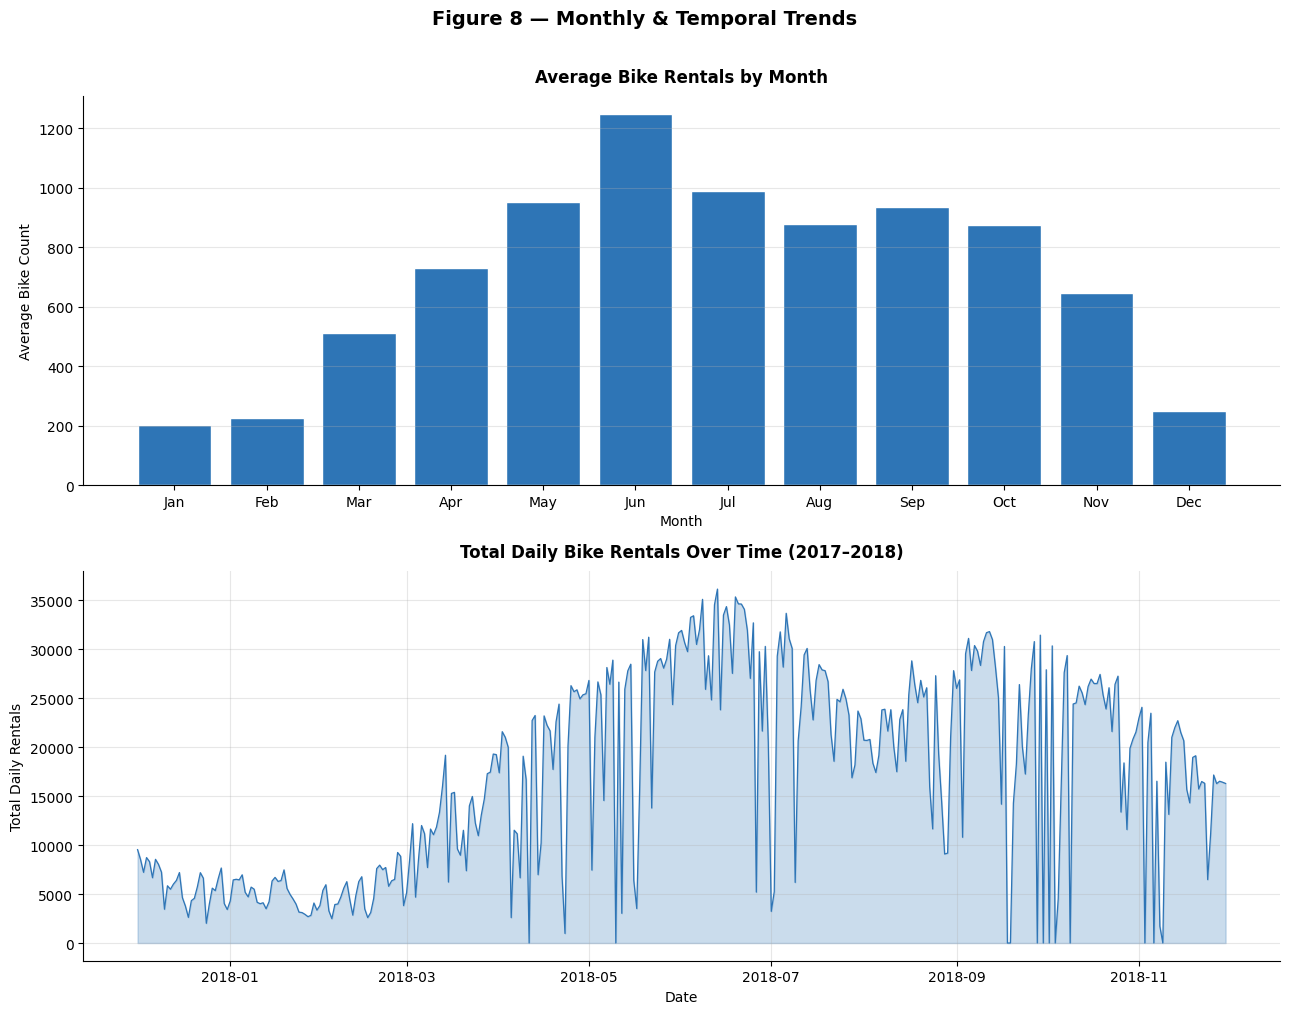

Monthly averages:
  Jan: 202
  Feb: 226
  Mar: 512
  Apr: 728
  May: 950
  Jun: 1246
  Jul: 987
  Aug: 876
  Sep: 936
  Oct: 875
  Nov: 647
  Dec: 249


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
month_avg   = df.groupby('month')['rented_bike_count'].mean()
axes[0].bar(month_names, month_avg.values, color=BLUE, edgecolor='white')
axes[0].set_title('Average Bike Rentals by Month',
                  fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Bike Count')
axes[0].grid(True, axis='y', alpha=0.3)

daily = df.groupby('date')['rented_bike_count'].sum()
axes[1].plot(daily.index, daily.values, color=BLUE, linewidth=0.9)
axes[1].fill_between(daily.index, daily.values, alpha=0.25, color=BLUE)
axes[1].set_title('Total Daily Bike Rentals Over Time (2017\u20132018)',
                  fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Daily Rentals')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 8 \u2014 Monthly & Temporal Trends',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig8_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Monthly averages:')
for name, val in zip(month_names, month_avg.values):
    print(f'  {name}: {val:.0f}')

## Figure 9 — Ranked Feature Correlations with Target *(New)*
**Report placement:** Section 5.1 → *Relationships Between Features and Target*  
Directly supports the ranked list of correlations described in the text (cleaner complement to the heatmap)

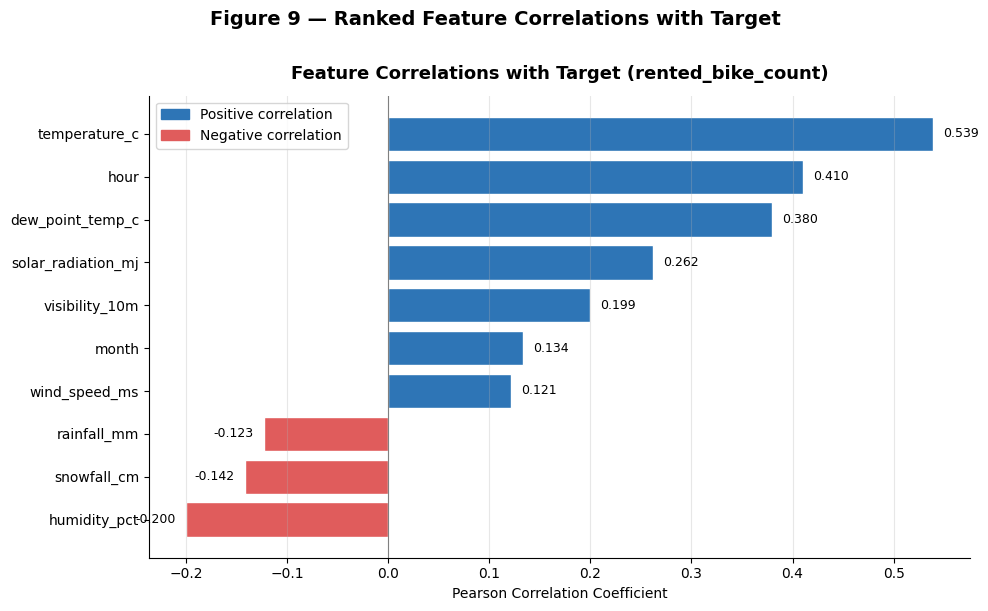

temperature_c         0.538558
hour                  0.410257
dew_point_temp_c      0.379788
solar_radiation_mj    0.261837
visibility_10m        0.199280
month                 0.133514
wind_speed_ms         0.121108
rainfall_mm          -0.123074
snowfall_cm          -0.141804
humidity_pct         -0.199780


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

corr_vals = (df[NUMERIC_COLS].corr()['rented_bike_count']
               .drop('rented_bike_count')
               .sort_values())
colors = [CORAL if v < 0 else BLUE for v in corr_vals.values]
bars   = ax.barh(corr_vals.index, corr_vals.values,
                 color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Feature Correlations with Target (rented_bike_count)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Pearson Correlation Coefficient')
for bar, val in zip(bars, corr_vals.values):
    offset = 0.01 if val >= 0 else -0.01
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9)

pos_patch = mpatches.Patch(color=BLUE,  label='Positive correlation')
neg_patch = mpatches.Patch(color=CORAL, label='Negative correlation')
ax.legend(handles=[pos_patch, neg_patch])
ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Figure 9 \u2014 Ranked Feature Correlations with Target',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig9_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr_vals.sort_values(ascending=False).to_string())

## Figure 10 — Zero-Inflated Features *(New)*
**Report placement:** Section 5.1 → *Distributions*  
Supports: *"Solar radiation, rainfall, and snowfall are zero-inflated, as night-time and precipitation-free hours dominate"*

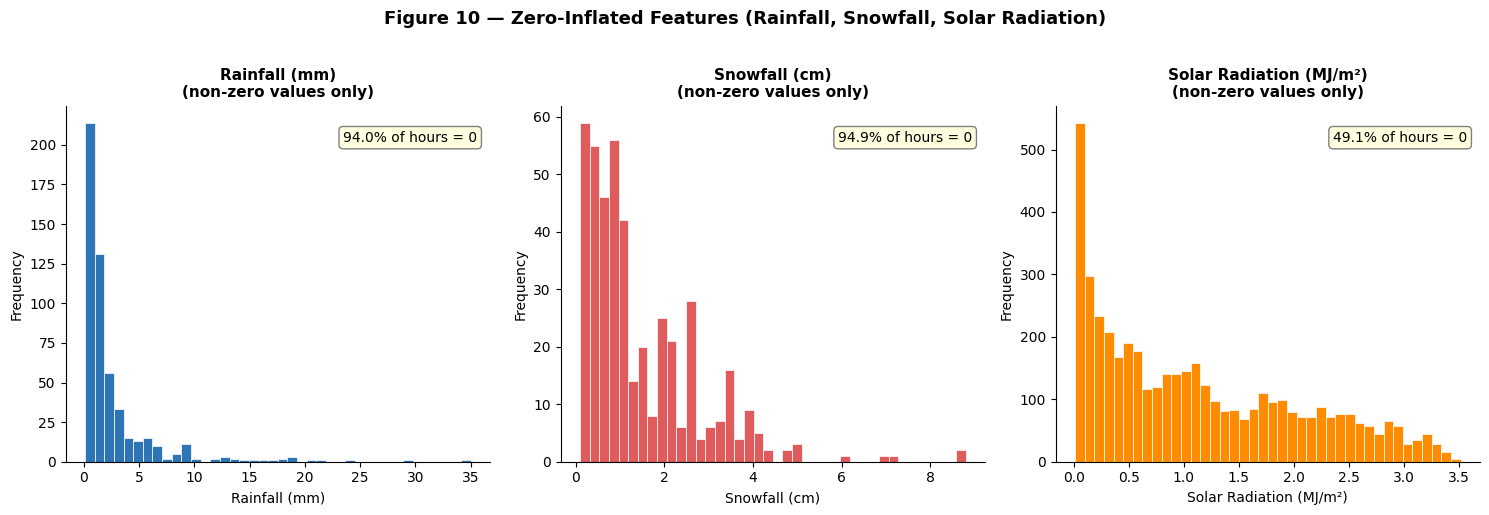

Rainfall (mm): 94.0% zeros
Snowfall (cm): 94.9% zeros
Solar Radiation (MJ/m²): 49.1% zeros


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

zero_feats = [
    ('rainfall_mm',        'Rainfall (mm)',             BLUE),
    ('snowfall_cm',        'Snowfall (cm)',              CORAL),
    ('solar_radiation_mj', 'Solar Radiation (MJ/m\u00b2)', AMBER),
]
for ax, (col, label, clr) in zip(axes, zero_feats):
    pct_zero = (df[col] == 0).mean() * 100
    nonzero  = df[df[col] > 0][col]
    ax.hist(nonzero, bins=40, color=clr, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{label}\n(non-zero values only)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.text(0.97, 0.93, f'{pct_zero:.1f}% of hours = 0',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='lightyellow', edgecolor='gray'))

plt.suptitle('Figure 10 \u2014 Zero-Inflated Features '
             '(Rainfall, Snowfall, Solar Radiation)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig10_zero_inflated.png', dpi=150, bbox_inches='tight')
plt.show()
for col, label, _ in zero_feats:
    pct = (df[col] == 0).mean() * 100
    print(f'{label}: {pct:.1f}% zeros')

## Figure 11 — Temperature Bimodal Distribution & Dew Point Collinearity *(New)*
**Report placement:** Section 5.1 → *Distributions* (bimodal) + *Relationships Between Feature Variables* (collinearity)  
Supports: *"Temperature follows a bimodal distribution reflecting Korea's seasonal cycle"* and *"Temperature and dew point exhibit strong collinearity"*

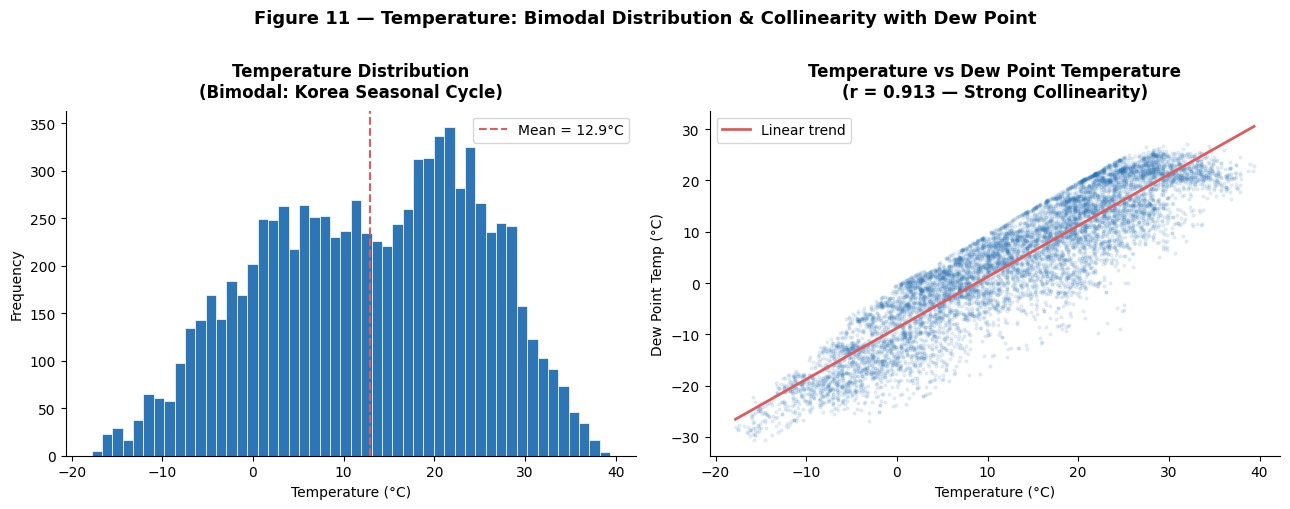

Temperature–Dew Point correlation: 0.913


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['temperature_c'], bins=50, color=BLUE,
             edgecolor='white', linewidth=0.5)
axes[0].set_title('Temperature Distribution\n(Bimodal: Korea Seasonal Cycle)',
                  fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Temperature (\u00b0C)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['temperature_c'].mean(), color=CORAL,
                linestyle='--', linewidth=1.5,
                label=f'Mean = {df["temperature_c"].mean():.1f}\u00b0C')
axes[0].legend()

r_dew = df['temperature_c'].corr(df['dew_point_temp_c'])
axes[1].scatter(df['temperature_c'], df['dew_point_temp_c'],
                alpha=0.1, s=4, color=BLUE)
axes[1].set_title(f'Temperature vs Dew Point Temperature\n'
                  f'(r = {r_dew:.3f} \u2014 Strong Collinearity)',
                  fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Temperature (\u00b0C)')
axes[1].set_ylabel('Dew Point Temp (\u00b0C)')
m, b = np.polyfit(df['temperature_c'], df['dew_point_temp_c'], 1)
x_line = np.linspace(df['temperature_c'].min(), df['temperature_c'].max(), 100)
axes[1].plot(x_line, m * x_line + b, color=CORAL,
             linewidth=2, label='Linear trend')
axes[1].legend()

plt.suptitle('Figure 11 \u2014 Temperature: Bimodal Distribution & '
             'Collinearity with Dew Point',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig11_temp_bimodal_collinearity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Temperature\u2013Dew Point correlation: {r_dew:.3f}')

## Figure 12 — Model Performance Comparison *(New)*
**Report placement:** Section 6.1 → *Model Performance Evaluation*  
Supports: *"Ridge R²=0.336, Random Forest R²=0.666, XGBoost R²=0.792"*

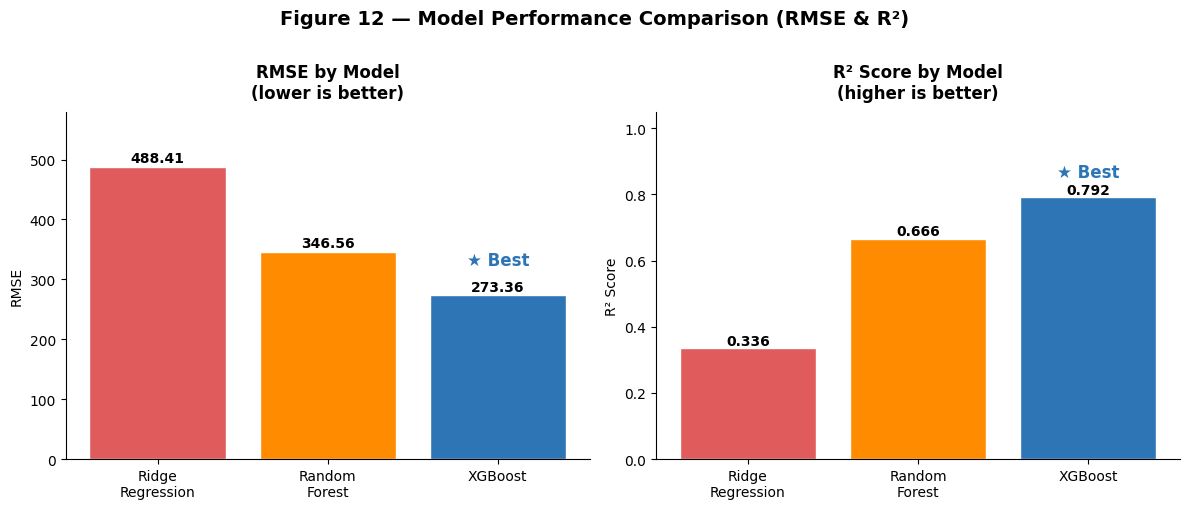

Model results:
  Ridge Regression      RMSE=488.41  R²=0.336
  Random Forest         RMSE=346.56  R²=0.666
  XGBoost               RMSE=273.36  R²=0.792


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models    = ['Ridge\nRegression', 'Random\nForest', 'XGBoost']
rmse_vals = [488.41, 346.56, 273.36]
r2_vals   = [0.336,  0.666,  0.792]
bar_cols  = [CORAL, AMBER, BLUE]

b1 = axes[0].bar(models, rmse_vals, color=bar_cols, edgecolor='white')
axes[0].set_title('RMSE by Model\n(lower is better)',
                  fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, 580)
for bar, v in zip(b1, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 8,
                 f'{v:.2f}', ha='center', fontweight='bold')
axes[0].text(2, rmse_vals[2] + 50, '\u2605 Best',
             ha='center', color=BLUE, fontweight='bold', fontsize=12)

b2 = axes[1].bar(models, r2_vals, color=bar_cols, edgecolor='white')
axes[1].set_title('R\u00b2 Score by Model\n(higher is better)',
                  fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('R\u00b2 Score')
axes[1].set_ylim(0, 1.05)
for bar, v in zip(b2, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                 f'{v:.3f}', ha='center', fontweight='bold')
axes[1].text(2, r2_vals[2] + 0.06, '\u2605 Best',
             ha='center', color=BLUE, fontweight='bold', fontsize=12)

plt.suptitle('Figure 12 \u2014 Model Performance Comparison (RMSE & R\u00b2)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Model results:')
for m, r, r2 in zip(models, rmse_vals, r2_vals):
    print(f'  {m.replace(chr(10), " "):20s}  RMSE={r:.2f}  R\u00b2={r2:.3f}')

## Summary

In [17]:
print('=' * 55)
print('       SEOUL BIKE SHARING \u2014 EDA SUMMARY')
print('=' * 55)
print(f'Rows              : {len(df):,}')
print(f'Features          : {len(df.columns)}')
print(f'Date range        : {df["date"].min().date()} \u2192 {df["date"].max().date()}')
print(f'Missing values    : None')
print(f'Duplicates        : None')
print(f'Non-functioning   : {(df["functioning_day"]=="No").sum()} rows')
print(f'Target skewness   : {df["rented_bike_count"].skew():.2f}')
print(f'Max hourly demand : {df["rented_bike_count"].max():,}')
print(f'Top corr w/ target: temperature_c ({df["temperature_c"].corr(df["rented_bike_count"]):.3f})')
print(f'Figures saved to  : ./figures/')
print('=' * 55)

       SEOUL BIKE SHARING — EDA SUMMARY
Rows              : 8,760
Features          : 17
Date range        : 2017-12-01 → 2018-11-30
Missing values    : None
Duplicates        : None
Non-functioning   : 295 rows
Target skewness   : 1.15
Max hourly demand : 3,556
Top corr w/ target: temperature_c (0.539)
Figures saved to  : ./figures/
